# Build Sentinel-3 Data Cubes


`xcube-eopf` is a Python package that extends [xcube](https://xcube.readthedocs.io/en/latest) with a new [data store](https://xcube.readthedocs.io/en/latest/dataaccess.html#available-data-stores) called `"eopf-zarr"`. This plugin enables the creation of analysis-ready data cubes (ARDC) from multiple Sentinel products published by the [EOPF Sentinel Zarr Sample Service](https://zarr.eopf.copernicus.eu/).

In this notebook, we demonstrate how to use the **xcube EOPF data store** to access multiple **Sentinel-3** EOPF Zarr products and generate 3D analysis-ready data cubes (ARDC).

For a general introduction to the xcube EOPF Data Store, see the [introduction notebook](https://eopf-sample-service.github.io/xcube-eopf/examples/introduction/).  

- 🐙 **GitHub:** [EOPF Sample Service – xcube-eopf](https://github.com/EOPF-Sample-Service/xcube-eopf)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xcube-eopf/issues)  
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xcube-eopf/)

---

## Main Features of the xcube-eopf Data Store for Sentinel-3

Sentinel-3 has two instruments on board: 

🌊 **OLCI — Ocean and Land Colour Instrument**

- **Purpose**: Primarily designed for ocean and land surface monitoring.
- **Spectral bands**: 21 bands (400–1020 nm).
- **Spatial resolution**: 300 m.
- **Swath width**: ~1,270 km

🔥 **SLSTR — Sea and Land Surface Temperature Radiometer**

- **Purpose**: Measures global sea and land surface temperatures with high accuracy.
- **Spectral bands**: 9 bands (visible to thermal infrared, 0.55–12 μm).
- **Spatial resolution**: 500 m (visible & shortwave infrared bands) and 1 km 
  (thermal infrared bands).
- **Swath width**: ~1,400 km

Sentinel-3 data products are distributed as **STAC Items**, where each item 
corresponds to a single tile. The datasets are provided in their 
**native 2D irregular grid** and typically require rectification for analysis-ready 
applications. 

**Data Cube Generation Workflow**

The workflow for building 3D analysis-ready cubes from Sentinel-3 products involves 
the following steps:

1. **Query** tiles using the [EOPF Zarr Sample Service STAC API](https://stac.core.eopf.eodc.eu/) for a given time range and 
   spatial extent.
2. **Group** items by solar day and orbit direction (ascending and descending passes).
3. **Rectify** data from the native 2D irregular grid to a regular grid using 
   [xcube-resampling](https://xcube-dev.github.io/xcube-resampling/guide/#3-rectification).
4. **Mosaic** adjacent tiles into seamless daily scenes.
5. **Stack** the daily mosaics along the temporal axis to form 3D data cubes 
   for each variable (e.g., spectral bands).

> **Note:** Rectification (irregular → regular grid) is computationally expensive and may slow down cube generation.  

📚 **More info:** [xcube-eopf Sentinel-3 Documentation](https://eopf-sample-service.github.io/xcube-eopf/guide/#sentinel-3)

---

## Import Modules

The `xcube-eopf` data store is provided as a plugin for `xcube`. Once installed, it registers automatically, allowing you to import `xcube` just like any other [xcube data store](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-access):

In [1]:
import matplotlib.pyplot as plt
from xcube.core.store import new_data_store
from xcube_resampling.utils import reproject_bbox

## Access Sentinel-3 ARDC

In this section, we demonstrate the available features and options for opening and generating spatio-temporal data cubes from multiple Sentinel-3 products.  
To initialize an `eopf-zarr` data store, run the cell below:

In [2]:
store = new_data_store("eopf-zarr")

The data IDs refer to STAC collections available via the [STAC Browser](https://stac.browser.user.eopf.eodc.eu). The following cell demonstrates how to list the available data IDs.

For Sentinel-3, the following STAC collections are currently accessible through xcube-eopf:

| Data ID                   | Description                                                           |
|---------------------------|-----------------------------------------------------------------------|
| ["sentinel-3-olci-l1-efr"](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-olci-l1-efr)  | Level-1 full-resolution top-of-atmosphere radiances from OLCI         |
| ["sentinel-3-olci-l2-lfr"](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-olci-l2-lfr)  | Level-2 land and atmospheric geophysical parameters derived from OLCI |
| ["sentinel-3-slstr-l1-rbt"](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-slstr-l1-rbt) | Level-1 radiances and brightness temperatures from SLSTR              |
| ["sentinel-3-slstr-l2-lst"](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-slstr-l2-lst) | Level-2 land surface temperature products from SLSTR                  |

In [3]:
store.list_data_ids()

['sentinel-2-l1c',
 'sentinel-2-l2a',
 'sentinel-3-olci-l1-efr',
 'sentinel-3-olci-l2-lfr',
 'sentinel-3-slstr-l1-rbt',
 'sentinel-3-slstr-l2-lst']

### Access Sentinel-3 OLCI L1 EFR ARDC

Below, you can explore the parameters of the `open_data()` method for each supported data product. The following cell generates a JSON schema listing all available opening parameters for Sentinel-3 OLCI L1 EFR products.

In [4]:
store.get_open_data_params_schema(data_id="sentinel-3-olci-l1-efr")

Next, we generate a data cube by setting the `data_id` to `"sentinel-3-olci-l1-efr"`. The spatial extent is defined using a bounding box over Northern Germany, while the temporal range is restricted to a few days in March 2026. The coordinate reference system (CRS) is set to WGS84 (EPSG:4326) by default.

In [5]:
bbox = [8.5, 53.0, 11.5, 55.0]
time_range = ["2026-03-03", "2026-03-05"]
resolution = 300 # meter
variables = ["oa02_radiance", "oa04_radiance", "oa06_radiance"] # RGB bands

In [6]:
%%time
ds = store.open_data(
    data_id="sentinel-3-olci-l1-efr",
    bbox=bbox,
    time_range=time_range,
    spatial_res=resolution / 111320, # conversion to degree approx.
    variables=variables,
)
ds

CPU times: user 15.7 s, sys: 2.29 s, total: 18 s
Wall time: 50.6 s


<xarray.Dataset> Size: 60MB
Dimensions:        (time: 3, lat: 743, lon: 1114)
Coordinates:
  * time           (time) datetime64[s] 24B 2026-03-03T09:37:31 ... 2026-03-0...
  * lat            (lat) float64 6kB 55.0 55.0 55.0 54.99 ... 53.01 53.0 53.0
  * lon            (lon) float64 9kB 8.501 8.504 8.507 8.509 ... 11.5 11.5 11.5
    spatial_ref    int64 8B 0
Data variables:
    oa02_radiance  (time, lat, lon) float64 20MB dask.array<chunksize=(1, 743, 1114), meta=np.ndarray>
    oa04_radiance  (time, lat, lon) float64 20MB dask.array<chunksize=(1, 743, 1114), meta=np.ndarray>
    oa06_radiance  (time, lat, lon) float64 20MB dask.array<chunksize=(1, 743, 1114), meta=np.ndarray>
Attributes: (14)

Note that the 3D datacube generation is fully **lazy**. Actual data download and processing (e.g., mosaicking, stacking) are performed **on demand** and are only triggered when the data is written or visualized.  

As an example, the next cell plots a single timestamp of the red band (`oa06_radiance`).

CPU times: user 3.71 s, sys: 795 ms, total: 4.51 s
Wall time: 2.51 s


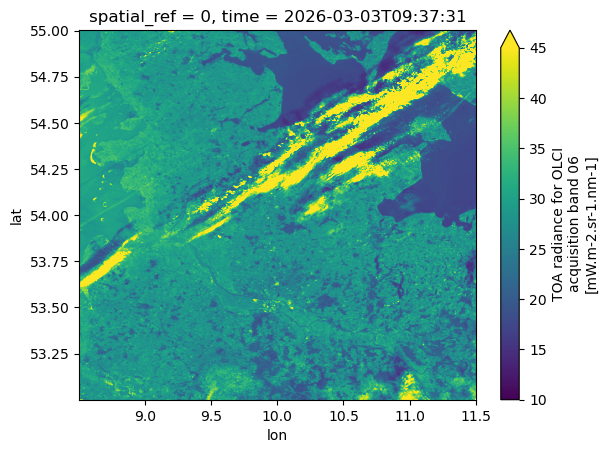

In [7]:
%%time
ds.oa06_radiance.isel(time=0).plot(vmin=10, vmax=45)

We can also request the same data cube in a different coordinate reference system (CRS), such as UTM. The xcube-eopf framework supports on-the-fly reprojection to any user-defined CRS.

Resampling behavior can be customized if needed. By default, bilinear interpolation is applied to floating-point data, while nearest-neighbor interpolation is used for integer data. For aggregation, float arrays use averaging, and integer arrays use a center-based approach. (see [xcube-resampling docuementation](https://xcube-dev.github.io/xcube-resampling/guide/#common-parameters-for-all-resampling-algorithms))

If the requested spatial resolution is coarser than the native resolution, the data are first aggregated and then reprojected, with interpolation applied during the reprojection step.

In [8]:
crs_utm = "EPSG:32632"
bbox_utm = reproject_bbox(bbox, "EPSG:4326", crs_utm)

In [9]:
%%time
ds = store.open_data(
    data_id="sentinel-3-olci-l1-efr",
    bbox=bbox_utm,
    time_range=time_range,
    spatial_res=resolution,
    variables=variables,
    crs=crs_utm,
    interp_methods="nearest",
    agg_methods="center",
)
ds

CPU times: user 23.3 s, sys: 2.29 s, total: 25.6 s
Wall time: 54.5 s


<xarray.Dataset> Size: 36MB
Dimensions:        (time: 3, y: 752, x: 672)
Coordinates:
  * time           (time) datetime64[s] 24B 2026-03-03T09:37:31 ... 2026-03-0...
  * y              (y) float64 6kB 6.098e+06 6.097e+06 ... 5.873e+06 5.872e+06
  * x              (x) float64 5kB 4.666e+05 4.669e+05 ... 6.676e+05 6.679e+05
    spatial_ref    int64 8B 0
Data variables:
    oa02_radiance  (time, y, x) float64 12MB dask.array<chunksize=(1, 752, 672), meta=np.ndarray>
    oa04_radiance  (time, y, x) float64 12MB dask.array<chunksize=(1, 752, 672), meta=np.ndarray>
    oa06_radiance  (time, y, x) float64 12MB dask.array<chunksize=(1, 752, 672), meta=np.ndarray>
Attributes: (14)

CPU times: user 2.11 s, sys: 347 ms, total: 2.46 s
Wall time: 1.66 s


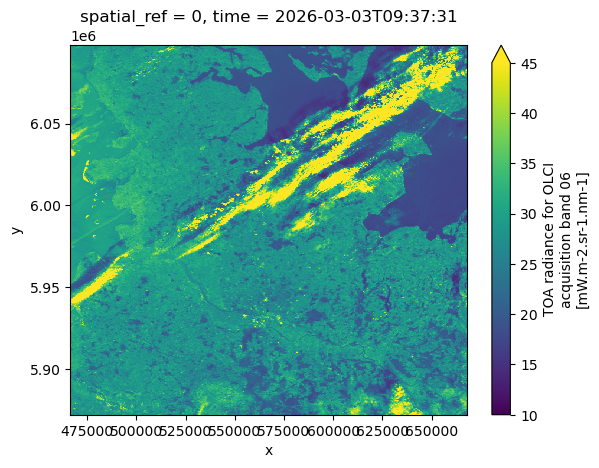

In [10]:
%%time
ds.oa06_radiance.isel(time=0).plot(vmin=10, vmax=45)

### Access Sentinel-3 OLCI Level-2 LFR ARDC

We now want to generate a similar data cube from the Sentinel-3 OLCI Level-2 LFR product. We therefore assign `data_id` to `"sentinel-3-olci-l2-lfr"`.

In [11]:
%%time
ds = store.open_data(
    data_id="sentinel-3-olci-l2-lfr",
    bbox=bbox,
    time_range=time_range,
    spatial_res=resolution / 111320,  # conversion to degree approx.
)
ds

CPU times: user 15.8 s, sys: 2.17 s, total: 17.9 s
Wall time: 48 s


<xarray.Dataset> Size: 99MB
Dimensions:      (time: 3, lat: 743, lon: 1114)
Coordinates:
  * time         (time) datetime64[s] 24B 2026-03-03T09:37:31 ... 2026-03-05T...
  * lat          (lat) float64 6kB 55.0 55.0 55.0 54.99 ... 53.01 53.0 53.0
  * lon          (lon) float64 9kB 8.501 8.504 8.507 8.509 ... 11.5 11.5 11.5
    spatial_ref  int64 8B 0
Data variables:
    gifapar      (time, lat, lon) float64 20MB dask.array<chunksize=(1, 743, 1114), meta=np.ndarray>
    iwv          (time, lat, lon) float64 20MB dask.array<chunksize=(1, 743, 1114), meta=np.ndarray>
    otci         (time, lat, lon) float64 20MB dask.array<chunksize=(1, 743, 1114), meta=np.ndarray>
    rc681        (time, lat, lon) float64 20MB dask.array<chunksize=(1, 743, 1114), meta=np.ndarray>
    rc865        (time, lat, lon) float64 20MB dask.array<chunksize=(1, 743, 1114), meta=np.ndarray>
Attributes: (15)

CPU times: user 2.83 s, sys: 606 ms, total: 3.44 s
Wall time: 1.44 s


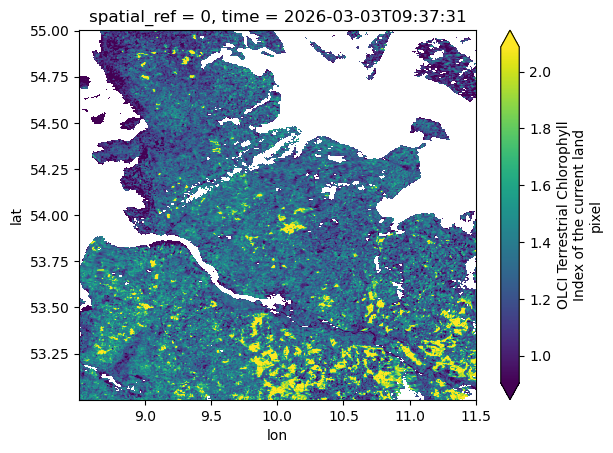

In [12]:
%%time
ds.otci.isel(time=0).plot(robust=True)

### Access Sentinel-3 SLSTR Level-2 LST 

Next, we want to generate a similar data cube from the Sentinel-3 SLSTR Level-2 LST product. We therefore assign `data_id` to `"sentinel-3-slstr-l2-lst"`.

For SLSTR products, a terrain correction is applied during this process. This is
necessary because the original geolocation is corrected only for Earth curvature,
but not for terrain variability caused by topography. See the
[SLSTR product description](https://sentiwiki.copernicus.eu/web/slstr-products)
for details.

In [13]:
%%time
ds = store.open_data(
    data_id="sentinel-3-slstr-l2-lst",
    bbox=bbox,
    time_range=time_range,
    spatial_res=resolution / 111320,  # conversion to degree approx.
)
ds

CPU times: user 1min 54s, sys: 2.67 s, total: 1min 57s
Wall time: 2min 21s


<xarray.Dataset> Size: 40MB
Dimensions:      (time: 6, lat: 743, lon: 1114)
Coordinates:
  * time         (time) datetime64[s] 48B 2026-03-03T09:37:31 ... 2026-03-05T...
  * lat          (lat) float64 6kB 55.0 55.0 55.0 54.99 ... 53.01 53.0 53.0
  * lon          (lon) float64 9kB 8.501 8.504 8.507 8.509 ... 11.5 11.5 11.5
    spatial_ref  int64 8B 0
Data variables:
    lst          (time, lat, lon) float64 40MB dask.array<chunksize=(1, 743, 1114), meta=np.ndarray>
Attributes: (21)

CPU times: user 375 ms, sys: 116 ms, total: 491 ms
Wall time: 694 ms


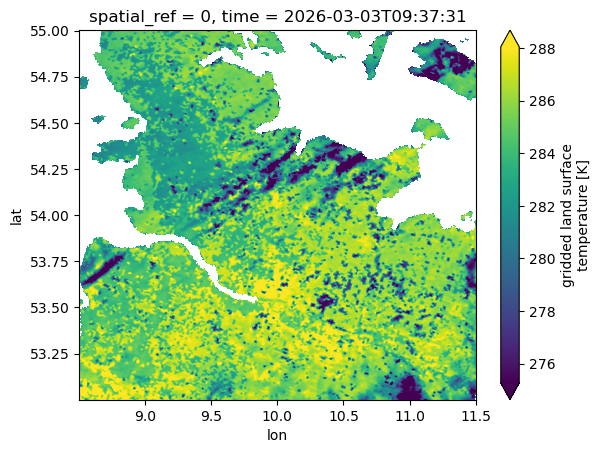

In [14]:
%%time
ds.lst.isel(time=0).plot(robust=True)

### Access Sentinel-3 SLSTR Level-1B RBT

Lastly, we generate a similar data cube from the Sentinel-3 SLSTR Level-1B RBT product by setting `data_id` to `"sentinel-3-slstr-l1-rbt"`.

The SLSTR instrument provides observations from two viewing geometries: **nadir** and **oblique** (forward view). These are designed to improve atmospheric correction and enable more accurate surface measurements.

Accordingly, many variables in the RBT product are available in pairs:
- `*_an` → **nadir view** (e.g. `s1_radiance_an`)
- `*_ao` → **oblique view** (e.g. `s1_radiance_ao`)

In the next example, we request both views for the S1 thermal channel. 

In [15]:
%%time
ds = store.open_data(
    data_id="sentinel-3-slstr-l1-rbt",
    bbox=bbox,
    time_range=time_range,
    spatial_res=resolution / 111320,  # conversion to degree approx.
    variables=["s1_radiance_an", "s1_radiance_ao"],
)
ds

CPU times: user 3min 32s, sys: 7.38 s, total: 3min 40s
Wall time: 10min 54s


<xarray.Dataset> Size: 79MB
Dimensions:         (time: 6, lat: 743, lon: 1114)
Coordinates:
  * time            (time) datetime64[s] 48B 2026-03-03T09:37:31 ... 2026-03-...
  * lat             (lat) float64 6kB 55.0 55.0 55.0 54.99 ... 53.01 53.0 53.0
  * lon             (lon) float64 9kB 8.501 8.504 8.507 8.509 ... 11.5 11.5 11.5
    spatial_ref     int64 8B 0
Data variables:
    s1_radiance_an  (time, lat, lon) float64 40MB dask.array<chunksize=(1, 743, 1114), meta=np.ndarray>
    s1_radiance_ao  (time, lat, lon) float64 40MB dask.array<chunksize=(1, 743, 1114), meta=np.ndarray>
Attributes: (95)

As an example, we plot the nadir and oblique views of the S1 thermal channel side by side.

CPU times: user 668 ms, sys: 125 ms, total: 793 ms
Wall time: 1.54 s


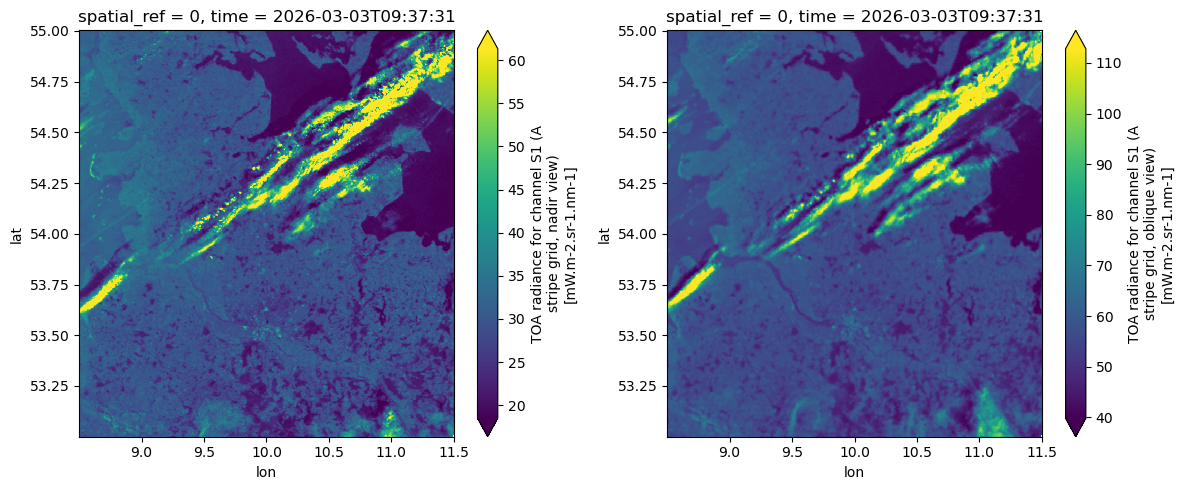

In [16]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ds.s1_radiance_an.isel(time=0).plot(ax=ax[0], robust=True)
ds.s1_radiance_ao.isel(time=0).plot(ax=ax[1], robust=True)
plt.tight_layout()

---

## Conclusion

This notebook highlighted the main features of the **xcube EOPF Data Store** for Sentinel-3, which enables seamless access to multiple EOPF Zarr products as **analysis-ready data cubes (ARDCs)**. 

Key takeaways:

- **3D spatio-temporal data cubes** can be generated from multiple EOPF Sentinel Zarr samples.  
- Supports access to **Sentinel-3 OLCI L1 EFR**, **Sentinel-3 OLCI Level-2 LFR**, **Sentinel-3 SLSTR Level-2 LST**, and **Sentinel-3 SLSTR Level-1B RBT** collections.  
- Data cubes can be requested with any **CRS**, spatial extent, temporal range, and spatial resolution.

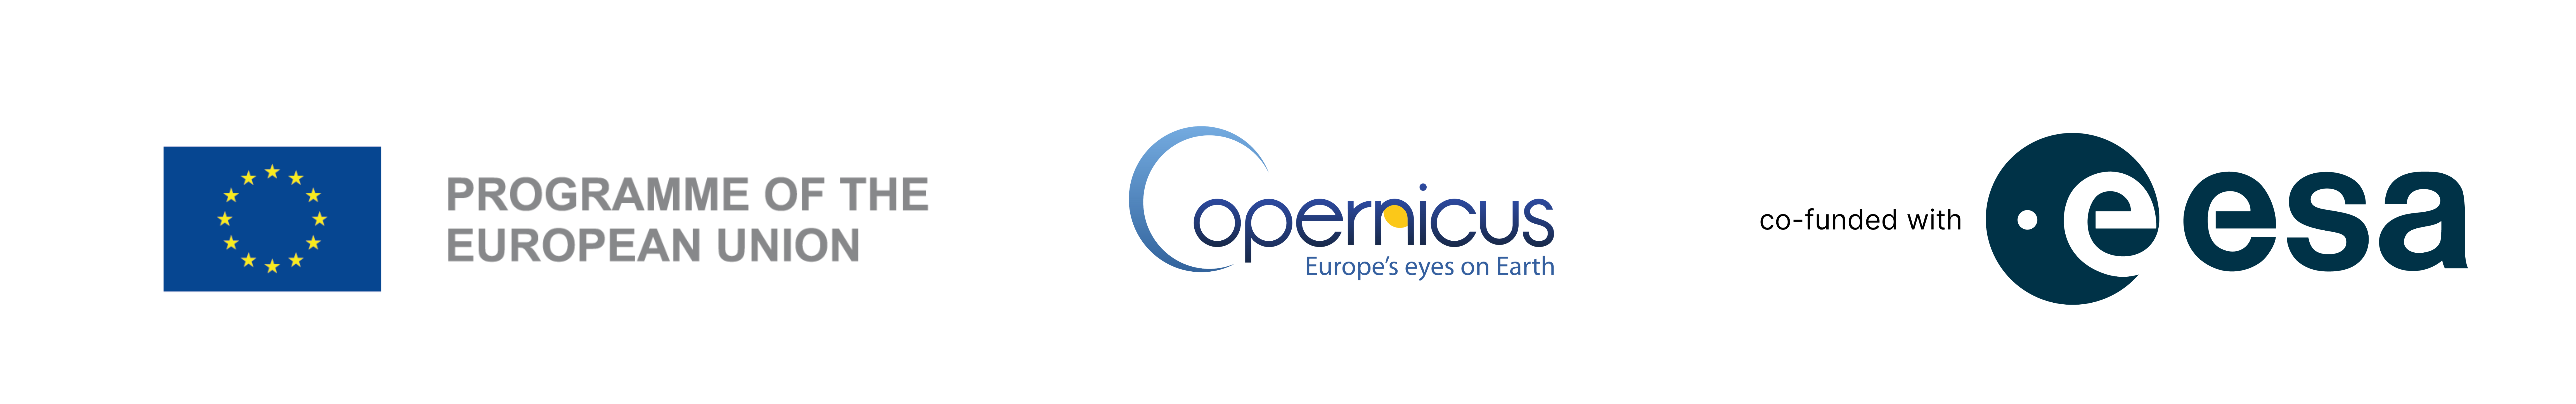